### ANES Open-Ended Coding Analysis

In [ ]:
# Setup
# ---------------------------------------------------


import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Import Data
# ---------------------------------------------------

df = pd.read_csv("data/master_dataframe.csv")


# Inspect
print(df.shape)
df.head()

(4960, 23)


,respondent_id,response_text,human_code_label,human_code,notes,llm_code_label,confidence,llm_code,gender,gender_label,race,race_label,marital_status,marital_status_label,income,income_label,education,education_label,occupation_status,occupation_status_label,age,party_id,party_id_label
0,140001,immigration we can't take care of our own peop...,NaN,NaN,NaN,Unclear,Low,10,1,man,3,hispanic,1,married,5,"$100,000-$249,999",4,bachelor's degree,1,working now,50,7,strong repbulican
1,140002,"The cost of everything, people can not afford ...",NaN,NaN,NaN,Unclear,Low,10,2,woman,4,asian,1,married,5,"$100,000-$249,999",3,some college,1,working now,41,4,independent
2,140003,threats to democracy,NaN,NaN,NaN,Unclear,Low,10,2,woman,1,"white, non-hispanic",1,married,5,"$100,000-$249,999",3,some college,7,homemaker,44,1,strong democrat
3,140004,economy and leadership.,NaN,NaN,NaN,Unclear,Low,10,1,man,4,asian,1,married,3,"$30,000-$59,999",3,some college,1,working now,45,6,not very strong republican
4,140005,"Economy, Border,",NaN,NaN,NaN,Economy,High,1,1,man,1,"white, non-hispanic",2,widowed,3,"$30,000-$59,999",5,graduate degree,5,retired,80,5,independent republican


In [ ]:
# Define Analytic Samples
# ---------------------------------------------------

# Sample A: Full LLM-coded sample (production)
df_full = df.copy()


# Sample B: High-confidence LLM-coded sample
df_high_conf = df[df["confidence"] == "High"].copy()


# Sample C: Human-coded validation sample (n ≈ 300)
df_human = df[~df["human_code_label"].isna()].copy()


print("Full sample:", df_full.shape)
print("High-confidence sample:", df_high_conf.shape)
print("Human-coded sample:", df_human.shape)

Full sample: (4960, 23)
High-confidence sample: (2687, 23)
Human-coded sample: (300, 23)


In [10]:
# Descriptive Distributions
# -------------------------------------------------

# Collapse Education categories

def collapse_education(label):
    if pd.isna(label):
        return "No info"
    label = label.lower()
    if "less than" in label:
        return "Less than HS"
    elif "high school" in label:
        return "High school"
    elif "some college" in label or "associate" in label:
        return "Some college"
    elif "bachelor" in label:
        return "Bachelor's"
    elif "graduate" in label or "postgraduate" in label:
        return "Graduate"
    elif "don" in label or "refused" in label or "insufficient" in label:
        return "No info"
    else:
        return "No info"

df_full["education_collapsed"] = df_full["education_label"].apply(collapse_education)

# Collapse Party ID categories

def collapse_party(label):
    if pd.isna(label):
        return "No info"
    label = label.lower()
    if "republican" in label and "independent" not in label:
        return "Republican"
    elif "democrat" in label and "independent" not in label:
        return "Democrat"
    elif "independent" in label:
        return "Independent"
    elif "don" in label or "refused" in label:
        return "No info"
    else:
        return "No info"


df_full["party_collapsed"] = df_full["party_id_label"].apply(collapse_party)

# Check distributions 
print(df_full["education_collapsed"].value_counts())
print(df_full["party_collapsed"].value_counts())



education_collapsed
Some college    1551
Bachelor's      1270
Graduate        1012
High school      850
Less than HS     233
No info           44
Name: count, dtype: int64
party_collapsed
Democrat       1772
Independent    1608
No info        1075
Republican      505
Name: count, dtype: int64


In [11]:
# ---------------------------------------------------
# Overall issue distribution (LLM)
# ---------------------------------------------------

issue_dist = (
df_full["llm_code_label"]
.value_counts(normalize=True)
.mul(100)
.round(1)
)

issue_dist

llm_code_label
Unclear               42.6
Economy               20.6
Politics/Democracy    10.2
Social Issues          9.7
Immigration            7.8
Healthcare             3.3
Crime                  2.0
Environment            1.6
Foreign Policy         1.1
Other                  1.0
Name: proportion, dtype: float64

### Overall Distribution

The most commonly cited issue (other than *Unclear*) is the *Economy* with about 20% of responses. The second most commonly cited issue is *Politics/Democracy*, and the third most commonly cited issue is *Social Issues*.

In [12]:
# --------------------------------------------------
# Issue by Party ID (row percentages)
# --------------------------------------------------

issue_party = (
pd.crosstab(
df_full["llm_code_label"],
df_full["party_collapsed"],
normalize="index"
)
.mul(100)
.round(1)
)


issue_party


party_collapsed,Democrat,Independent,No info,Republican
llm_code_label,,,,
Crime,40.8,27.6,15.3,16.3
Economy,26.2,35.9,23.5,14.4
Environment,66.2,27.5,5.0,1.2
Foreign Policy,19.3,35.1,24.6,21.1
Healthcare,53.4,32.5,8.0,6.1
Immigration,11.9,24.5,52.1,11.6
Other,35.4,45.8,12.5,6.2
Politics/Democracy,56.9,29.7,8.1,5.3
Social Issues,50.6,33.2,8.5,7.7


### Issue by Party ID

blah blah blah

In [13]:

# --------------------------------------------------
# Issue by Education (row percentages)
# --------------------------------------------------

issue_edu = (
pd.crosstab(
df_full["llm_code_label"],
df_full["education_collapsed"],
normalize="index"
)
.mul(100)
.round(1)
)


issue_edu

education_collapsed,Bachelor's,Graduate,High school,Less than HS,No info,Some college
llm_code_label,,,,,,
Crime,19.4,17.3,26.5,10.2,1.0,25.5
Economy,26.9,16.7,19.5,4.9,1.3,30.8
Environment,35.0,36.2,5.0,3.8,0.0,20.0
Foreign Policy,24.6,17.5,22.8,5.3,0.0,29.8
Healthcare,31.9,27.0,10.4,3.1,0.0,27.6
Immigration,18.8,16.8,21.1,4.1,0.8,38.4
Other,29.2,16.7,8.3,4.2,2.1,39.6
Politics/Democracy,30.9,30.5,9.1,1.6,1.2,26.8
Social Issues,27.4,23.9,15.8,2.5,0.4,30.1


### Issue by Education

blah blah blah

In [14]:
# Analyzing Unclear as an Outcome
# ---------------------------------------------

# Create binary indicator for Unclear
df_full["is_unclear"] = np.where(
df_full["llm_code_label"] == "Unclear", 1, 0
)

# Logistic regression predicting Unclear
unclear_model = smf.logit(
"is_unclear ~ C(education_collapsed) + C(party_collapsed) + age",
data=df_full
).fit()


unclear_model.summary()


Optimization terminated successfully.
         Current function value: 0.679082
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             is_unclear   No. Observations:                 4960
Model:                          Logit   Df Residuals:                     4950
Method:                           MLE   Df Model:                            9
Date:                Thu, 22 Jan 2026   Pseudo R-squ.:                0.004683
Time:                        12:41:41   Log-Likelihood:                -3368.2
converged:                       True   LL-Null:                       -3384.1
Covariance Type:            nonrobust   LLR p-value:                 0.0002249
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -0.5830      0.100     -5.849      0.000      -0.778      -0.388
C(education_collapsed)[T.Graduate]        -0.0078      0.087     -0.090      0.928      -0.177       0.162
C(education_collapsed)[T.High school]      0.1901      0.090      2.109      0.035       0.013       0.367
C(education_collapsed)[T.Less than HS]     0.5209      0.144      3.629      0.000       0.240       0.802
C(education_collapsed)[T.No info]          0.0120      0.313      0.038      0.969      -0.601       0.625
C(education_collapsed)[T.Some college]     0.1584      0.077      2.052      0.040       0.007       0.310
C(party_collapsed)[T.Independent]          0.0844      0.071      1.195      0.232      -0.054       0.223
C(party_collapsed)[T.No info]              0.1972      0.079      2.488      0.013       0.042       0.353
C(party_collapsed)[T.Republican]           0.0133      0.103      0.128      0.898      -0.189       0.216
age                                        0.0021      0.001      1.488      0.137      -0.001       0.005
==========================================================================================================
"""

### Analyzing *Unclear* as an Outcome

Education of "less than high school" was the strongest predictor of an LLM-coded *Unclear* response. Education of "high school" and "some college" were also significant. 

No info for Party ID also significantly predicted an LLM-coded *Unclear* response.

comparison category for education is college?
and democrat for party ID?

## Focused Substantive Models

In [15]:
# Economy vs all others
#-------------------------------------------------

df_full["economy_issue"] = np.where(
df_full["llm_code_label"] == "Economy", 1, 0
)

econ_model = smf.logit(
"economy_issue ~ C(party_collapsed) + C(education_collapsed) + income + age",
data=df_full
).fit()


econ_model.summary()

Optimization terminated successfully.
         Current function value: 0.499678
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          economy_issue   No. Observations:                 4960
Model:                          Logit   Df Residuals:                     4949
Method:                           MLE   Df Model:                           10
Date:                Thu, 22 Jan 2026   Pseudo R-squ.:                 0.01716
Time:                        12:49:00   Log-Likelihood:                -2478.4
converged:                       True   LL-Null:                       -2521.7
Covariance Type:            nonrobust   LLR p-value:                 2.588e-14
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -1.4201      0.126    -11.280      0.000      -1.667      -1.173
C(party_collapsed)[T.Independent]          0.4793      0.090      5.323      0.000       0.303       0.656
C(party_collapsed)[T.No info]              0.4615      0.100      4.594      0.000       0.265       0.658
C(party_collapsed)[T.Republican]           0.7960      0.119      6.676      0.000       0.562       1.030
C(education_collapsed)[T.Graduate]        -0.2683      0.109     -2.451      0.014      -0.483      -0.054
C(education_collapsed)[T.High school]      0.0794      0.108      0.737      0.461      -0.132       0.291
C(education_collapsed)[T.Less than HS]     0.0186      0.176      0.105      0.916      -0.327       0.364
C(education_collapsed)[T.No info]          0.5266      0.344      1.531      0.126      -0.148       1.201
C(education_collapsed)[T.Some college]    -0.0934      0.094     -0.993      0.321      -0.278       0.091
income                                     0.0180      0.012      1.513      0.130      -0.005       0.041
age                                       -0.0057      0.002     -3.262      0.001      -0.009      -0.002
==========================================================================================================
"""

independents, no info, and republicans all significantly more likely to cite economy as primary issue than democrats

graduate degree less likely than college to cite economy, otherwise no difference between college vs. lower education

younger indiviauls more likely to cite economy

In [16]:
# Politics/Democracy vs all others
# -------------------------------------------------------
df_full["pol_demo_issue"] = np.where(
df_full["llm_code_label"] == "Politics/Democracy", 1, 0
)


pol_model = smf.logit(
"pol_demo_issue ~ C(party_collapsed) + C(education_collapsed) + income + age",
data=df_full
).fit()


pol_model.summary()

Optimization terminated successfully.
         Current function value: 0.308907
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         pol_demo_issue   No. Observations:                 4960
Model:                          Logit   Df Residuals:                     4949
Method:                           MLE   Df Model:                           10
Date:                Thu, 22 Jan 2026   Pseudo R-squ.:                 0.06496
Time:                        12:53:01   Log-Likelihood:                -1532.2
converged:                       True   LL-Null:                       -1638.6
Covariance Type:            nonrobust   LLR p-value:                 3.299e-40
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -2.0537      0.173    -11.873      0.000      -2.393      -1.715
C(party_collapsed)[T.Independent]         -0.5273      0.109     -4.857      0.000      -0.740      -0.315
C(party_collapsed)[T.No info]             -1.5030      0.174     -8.654      0.000      -1.843      -1.163
C(party_collapsed)[T.Republican]          -1.1381      0.209     -5.435      0.000      -1.549      -0.728
C(education_collapsed)[T.Graduate]         0.1270      0.125      1.019      0.308      -0.117       0.371
C(education_collapsed)[T.High school]     -0.8186      0.177     -4.620      0.000      -1.166      -0.471
C(education_collapsed)[T.Less than HS]    -1.3695      0.374     -3.664      0.000      -2.102      -0.637
C(education_collapsed)[T.No info]          0.1293      0.462      0.280      0.780      -0.777       1.035
C(education_collapsed)[T.Some college]    -0.3468      0.126     -2.744      0.006      -0.595      -0.099
income                                    -0.0010      0.016     -0.059      0.953      -0.033       0.031
age                                        0.0111      0.003      4.397      0.000       0.006       0.016
==========================================================================================================
"""

independent, no info, and republicans less likely than democrats to cite politics/democracy as main issue

lower than bachelor's degree less likely than college educated to cite politics/democracy

older individuals more likely to cite politics/democracy

In [17]:
# --------------------------------------------------
#  Robustness check: High-confidence sample
# --------------------------------------------------

hc_issue_dist = (
df_high_conf["llm_code_label"]
.value_counts(normalize=True)
.mul(100)
.round(1)
)


hc_issue_dist

llm_code_label
Economy               36.5
Politics/Democracy    17.9
Social Issues         16.5
Immigration           14.0
Healthcare             5.4
Crime                  3.2
Environment            2.9
Foreign Policy         1.7
Other                  1.3
Unclear                0.6
Name: proportion, dtype: float64

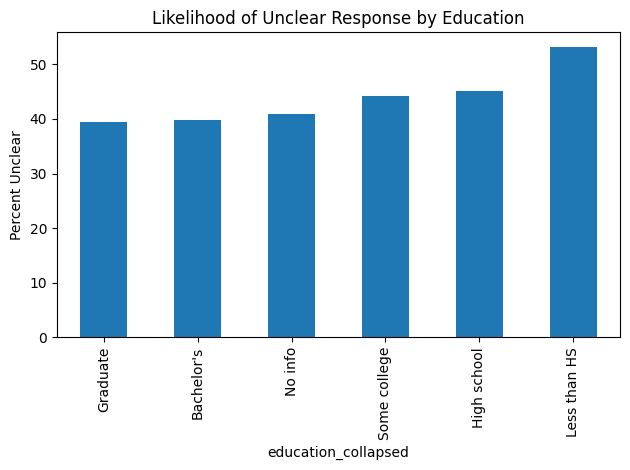

In [18]:
# --------------------------------------------------
# Unclear by education vis
# --------------------------------------------------


unclear_by_edu = (
df_full.groupby("education_collapsed")["is_unclear"].mean()
.mul(100)
.sort_values()
)


plt.figure()
unclear_by_edu.plot(kind="bar")
plt.ylabel("Percent Unclear")
plt.title("Likelihood of Unclear Response by Education")
plt.tight_layout()
plt.show()